<a href="https://colab.research.google.com/github/Rustam99-eng/Fine-tuning-EfficientNetV2-Stanford-Dogs/blob/main/Fine_tuning_EfficientNetV2_Stanford_Dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Проверим версию keras
import keras
print(keras.__version__)

3.13.2


In [2]:
# Импортируем необходимые библиотеки
import matplotlib.pyplot as plt
%matplotlib inline

from tensorflow import data as tf_data
import os
import keras
from keras import layers
from keras.applications import EfficientNetV2B0

IMAGE_SIZE = (224, 224) # Размер определен выбором модели
BATCH_SIZE = 128

In [3]:
!wget https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip

--2026-04-02 16:14:25--  https://storage.yandexcloud.net/academy.ai/stanford_dogs.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 774907490 (739M) [application/x-zip-compressed]
Saving to: ‘stanford_dogs.zip’

stanford_dogs.zip   100%[===================>] 739.01M  12.0MB/s    in 63s     

2026-04-02 16:15:29 (11.8 MB/s) - ‘stanford_dogs.zip’ saved [774907490/774907490]



In [4]:
# Разархивируем датасета во временную папку 'temp'
!unzip -qo "stanford_dogs" -d ./dataset

# Папка с папками картинок, рассортированных по категориям
IMAGE_PATH = './dataset/'

In [5]:
num_skipped = 0 # счетчик поврежденных файлов
for folder_name in os.listdir(IMAGE_PATH): # перебираем папки
    folder_path = os.path.join(IMAGE_PATH, folder_name) # склеиваем путь
    for fname in os.listdir(folder_path): # получаем список файлов в папке
        fpath = os.path.join(folder_path, fname) # получаем путь до файла
        try:
            fobj = open(fpath, "rb") # пытаемся открыть файл для бинарного чтения (rb)
            is_jfif = b"JFIF" in fobj.peek(10) # получаем первые 10 байт из файла и ищем в них бинарный вариант строки JFIF
        finally:
            fobj.close() # Закрываем файл

        if not is_jfif: # Если не нашли JFIF строку
            # Увеличиваем счетчик
            num_skipped += 1
            # Удаляем поврежденное изображение
            os.remove(fpath)

print(f"Удалено изображений: {num_skipped}")

Удалено изображений: 10


In [6]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    IMAGE_PATH, # путь к папке с данными
    validation_split=0.2, # отщепляем 20% на проверочную выборку
    subset="both", # указываем, что необходимо вернуть кортеж из обучающей и проверочной выборок ("training", "validation" или "both")
    seed=42,  # воспроизводимость результата генерации (результаты с одинаковым числом - одинаковы),
    shuffle=True, # перемешиваем датасет
    image_size=IMAGE_SIZE, # размер генерируемых изображений
    batch_size=BATCH_SIZE, # размер мини-батча
)

Found 20570 files belonging to 120 classes.
Using 16456 files for training.
Using 4114 files for validation.


In [7]:
# Определяем список имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определяем количества классов
CLASS_COUNT = len(CLASS_LIST)

# Вывод результата
print(f'Количество классов: {CLASS_COUNT}')
print(f'Метки классов: {CLASS_LIST}')

Количество классов: 120
Метки классов: ['Affenpinscher', 'Afghan_hound', 'African_hunting_dog', 'Airedale', 'American_Staffordshire_terrier', 'Appenzeller', 'Australian_terrier', 'Basenji', 'Basset', 'Beagle', 'Bedlington_terrier', 'Bernese_mountain_dog', 'Black-and-tan_coonhound', 'Blenheim_spaniel', 'Bloodhound', 'Bluetick', 'Border_collie', 'Border_terrier', 'Borzoi', 'Boston_bull', 'Bouvier_des_Flandres', 'Boxer', 'Brabancon_griffon', 'Briard', 'Brittany_spaniel', 'Bull_mastiff', 'Cairn', 'Cardigan', 'Chesapeake_Bay_retriever', 'Chihuahua', 'Chow', 'Clumber', 'Cocker_spaniel', 'Collie', 'Curly-coated_retriever', 'Dandie_Dinmont', 'Dhole', 'Dingo', 'Doberman', 'English_foxhound', 'English_setter', 'English_springer', 'EntleBucher', 'Eskimo_dog', 'Flat-coated_retriever', 'French_bulldog', 'German_shepherd', 'German_short-haired_pointer', 'Giant_schnauzer', 'Golden_retriever', 'Gordon_setter', 'Great_Dane', 'Great_Pyrenees', 'Greater_Swiss_Mountain_dog', 'Groenendael', 'Ibizan_hound',

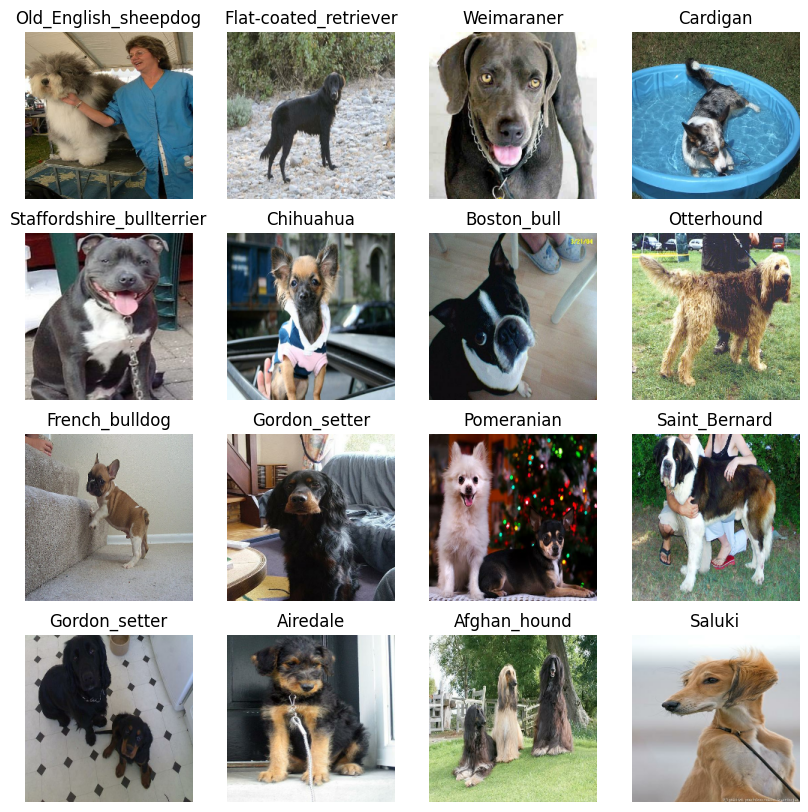

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # берем первый батч обучающей выборки
    for i in range(16): # отрисуем первые 16 картинок батча
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(images[i]).astype("uint8"))
        plt.title(CLASS_LIST[labels[i]]) # покажем метки
        plt.axis("off") # отключаем отображение осей

In [9]:
img_augmentation_layers = [
    layers.RandomRotation(factor=0.15), # Вращаем изображение в пределах 15%
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Сдвиг на 10% по вертикали и горизонтали
    layers.RandomFlip(), # Отражение по вертикали и горизонтали
    layers.RandomContrast(factor=0.1), # Изменяем контрастность на 10%
]


def img_augmentation(images):
    # Слои - это функции, которые мы последовательно применяем к входным данным
    for layer in img_augmentation_layers:
        images = layer(images)
    return images

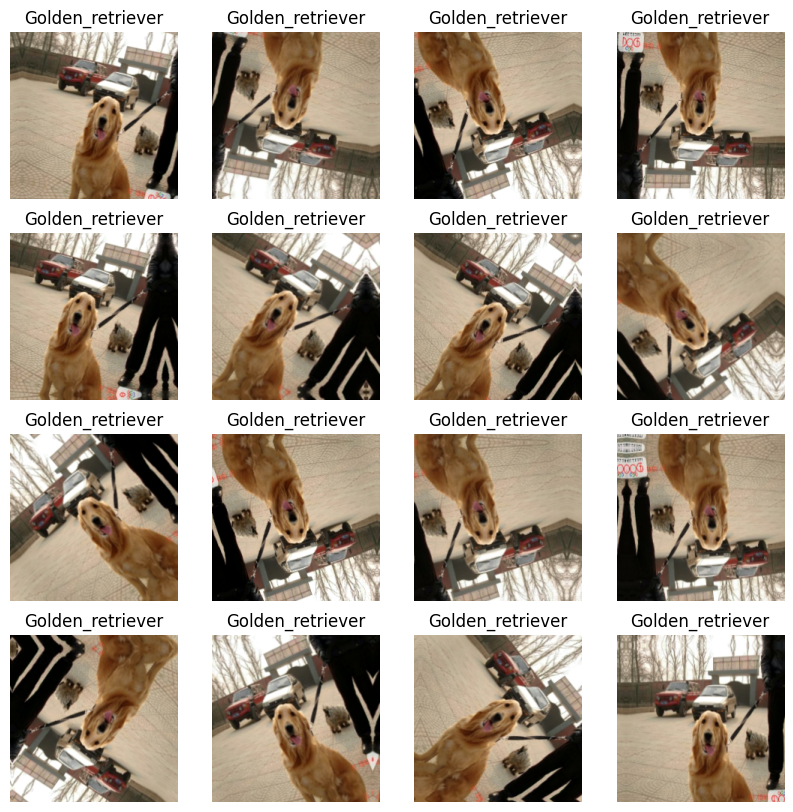

In [10]:
plt.figure(figsize=(10, 10))
for images, label in train_ds.take(1):
    for i in range(16):
        augmented_images = img_augmentation(images[0])
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(keras.utils.img_to_array(augmented_images).astype("uint8")) # Преобразуем картинку в тензор, теперь уже без NumPy
        plt.title("{}".format(CLASS_LIST[label[0]])) # Вывод метки
        plt.axis("off")

In [11]:
# Применяем `img_augmentation` к обучающей выборке
train_ds = train_ds.map(
    lambda img, label: (img_augmentation(img), keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

val_ds = val_ds.map(
    lambda img, label: (img, keras.ops.one_hot(label, CLASS_COUNT)), # One-hot кодирование
    num_parallel_calls=tf_data.AUTOTUNE, # число потоков для обработки в map (автонастройка зависит от возможностей процессора)
)

# Предварительная выборка примеров в память GPU или оперативную память
# Помогает максимально эффективно использовать графический процессор
train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)

In [12]:
def show_plot(history):
    acc = history.history['acc']
    epochs = range(1, len(acc) + 1)
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')
    plt.plot(epochs, val_acc, 'b', label='Точность на проверочной выборке')
    plt.title('График точности на обучающей и проверочной выборках')
    plt.legend()
    plt.figure()
    plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')
    plt.plot(epochs, val_loss, 'b', label='Потери на проверочной выборке')
    plt.title('График потерь на обучающей и проверочной выборках')
    plt.legend()
    plt.show()

In [13]:
def build_model(num_classes):
    inputs = layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    model = EfficientNetV2B0(include_top=False, input_tensor=inputs, weights="imagenet")

    # Заморозка предобученных весов
    model.trainable = False

    # Замена верхних слоев
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="pred")(x)

    # Компилируем
    model = keras.Model(inputs, outputs, name="EfficientNet")
    optimizer = keras.optimizers.Adam(learning_rate=1e-2)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["acc"]
    )
    return model

In [14]:
epochs = 20

callbacks = [
    keras.callbacks.EarlyStopping(
                    monitor='val_acc',
                    mode='max',
                    verbose=1,
                    min_delta=0.001,
                    patience = 5),

    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_acc',
                             save_best_only = True,
                             mode = 'max',
                             verbose = 1),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-4,
        verbose=1
)
]

model = build_model(num_classes=CLASS_COUNT)


history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3887 - loss: 3.3326
Epoch 1: val_acc improved from None to 0.80141, saving model to best_model_pretrain.keras

Epoch 1: finished saving model to best_model_pretrain.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - acc: 0.4702 - loss: 2.8249 - val_acc: 0.8014 - val_loss: 0.7106 - learning_rate: 0.0100
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.5898 - loss: 1.7031
Epoch 2: val_acc improved from 0.80141 to 0.82718, saving model to best_model_pretrain.keras

Epoch 2: finished saving model to best_model_pretrain.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - acc: 0.5885 - loss: 1.6465 - val_acc: 0.8272 - val_loss: 0.5796 - learning_rate: 0.0100
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.6247 - loss: 1.3479
Epoch 3: val_acc improved from 0.82718 to 0.84273, saving model to best_model_pretrain.keras

Epoch 3: finished saving model to best_model_p

 Выполним тонкую настройку (fine-tuning) модели

Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7614 - loss: 0.7881
Epoch 1: val_acc improved from None to 0.86753, saving model to best_model_pretrain.keras

Epoch 1: finished saving model to best_model_pretrain.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - acc: 0.7687 - loss: 0.7637 - val_acc: 0.8675 - val_loss: 0.4192 - learning_rate: 1.0000e-05
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7706 - loss: 0.7555
Epoch 2: val_acc did not improve from 0.86753
129/129 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - acc: 0.7705 - loss: 0.7480 - val_acc: 0.8673 - val_loss: 0.4204 - learning_rate: 1.0000e-05
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.7616 - loss: 0.7815
Epoch 3: val_acc did not improve from 0.86753
129/129 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - acc: 0.7662 - loss: 0.7639 - val_acc: 0.8668 - val_loss: 0.4218 - learning_rate: 1.0000e-05
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7658 - loss: 0.7757
Epoch 4: val_acc improved fro

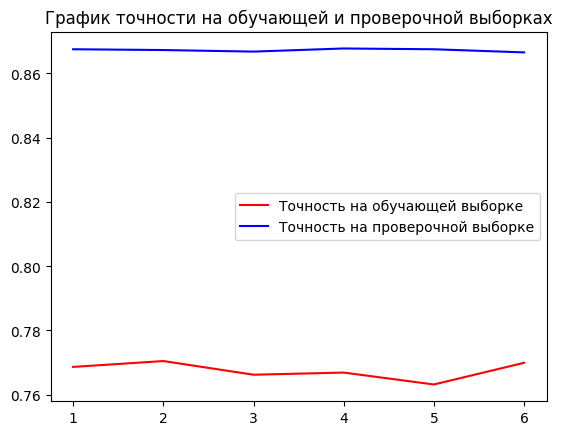

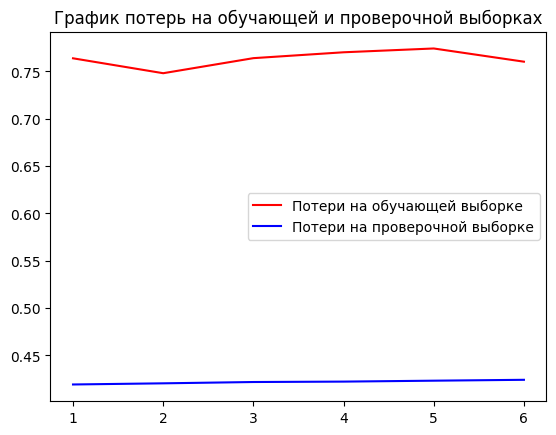

In [15]:
def unfreeze_model(model):
    # Мы размораживаем 20 верхних слоев за исключением BatchNormalization
    for layer in model.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True
    # В оптимизаторе устанавливаем маленький шаг обучения
    optimizer = keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["acc"]
    )


unfreeze_model(model)

callbacks = [
    keras.callbacks.EarlyStopping(
                    monitor='val_acc',
                    mode='max',
                    verbose=1,
                    min_delta=0.001,
                    patience = 5),

    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_acc',
                             save_best_only = True,
                             mode = 'max',
                             verbose = 1),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-4,
        verbose=1
)
]

epochs = 10
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)
show_plot(history)

In [16]:
#вывод точности после дообучения
final_train_acc_finetune = history.history['acc'][-1]
final_val_acc_finetune = history.history['val_acc'][-1]
print(f"\nФинальная точность после дообучения:")
print(f"Обучающая выборка: {final_train_acc_finetune:.4f}")
print(f"Валидационная выборка: {final_val_acc_finetune:.4f}")

#оценка на тестовой выборке
print("\nОценка на тестовой выборке:")
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test accuracy: {test_acc:.4f}")


Финальная точность после дообучения:
Обучающая выборка: 0.7699
Валидационная выборка: 0.8666

Оценка на тестовой выборке:
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - acc: 0.8666 - loss: 0.4241
Test accuracy: 0.8666


Проверим модель на собственных фотографиях, которых не было в обучающей и тестовой выборке

--2026-04-02 18:12:24--  https://storage.yandexcloud.net/my.files/retriever.jpg
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 130497 (127K) [image/jpeg]
Saving to: ‘retriever.jpg’

retriever.jpg       100%[===================>] 127.44K   158KB/s    in 0.8s    

2026-04-02 18:12:26 (158 KB/s) - ‘retriever.jpg’ saved [130497/130497]

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

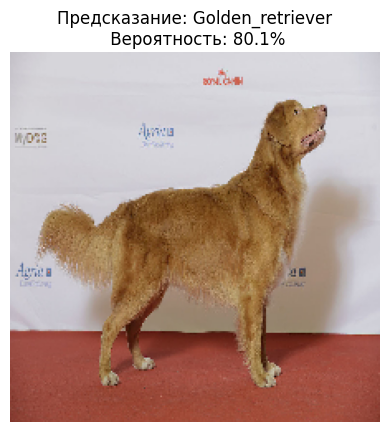

In [17]:
!wget https://storage.yandexcloud.net/my.files/retriever.jpg
TEST_IMG='./retriever.jpg'

img = keras.utils.load_img(TEST_IMG, target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1])) # Загружаем картинку
plt.imshow(img)


img_array = keras.utils.img_to_array(img) # Преобразуем картинку в тензор
img_array = keras.ops.expand_dims(img_array, 0)  # Создание дополнительного измерения для батча

predictions = model.predict(img_array)


plt.title("Предсказание: %s\n Вероятность: %2.1f%%" %
 (CLASS_LIST[keras.ops.argmax(predictions)],
  keras.ops.max(predictions)*100)  ) # Вывод метки
plt.axis("off")

--2026-04-02 18:39:47--  https://storage.yandexcloud.net/my.files/German%20Shepard.jpg
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1399789 (1.3M) [image/jpeg]
Saving to: ‘German Shepard.jpg.2’

German Shepard.jpg. 100%[===================>]   1.33M   781KB/s    in 1.7s    

2026-04-02 18:39:50 (781 KB/s) - ‘German Shepard.jpg.2’ saved [1399789/1399789]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

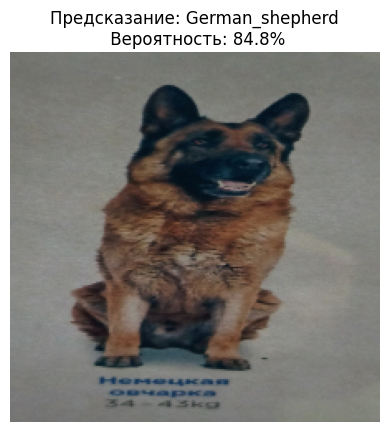

In [20]:
!wget https://storage.yandexcloud.net/my.files/German%20Shepard.jpg
TEST_IMG='/content/German Shepard.jpg'

img = keras.utils.load_img(TEST_IMG, target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1])) # Загружаем картинку
plt.imshow(img)


img_array = keras.utils.img_to_array(img) # Преобразуем картинку в тензор
img_array = keras.ops.expand_dims(img_array, 0)  # Создание дополнительного измерения для батча

predictions = model.predict(img_array)


plt.title("Предсказание: %s\n Вероятность: %2.1f%%" %
 (CLASS_LIST[keras.ops.argmax(predictions)],
  keras.ops.max(predictions)*100)  ) # Вывод метки
plt.axis("off")

--2026-04-02 18:42:09--  https://storage.yandexcloud.net/my.files/dog2.jpg
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1513205 (1.4M) [image/jpeg]
Saving to: ‘dog2.jpg’

dog2.jpg            100%[===================>]   1.44M   867KB/s    in 1.7s    

2026-04-02 18:42:12 (867 KB/s) - ‘dog2.jpg’ saved [1513205/1513205]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

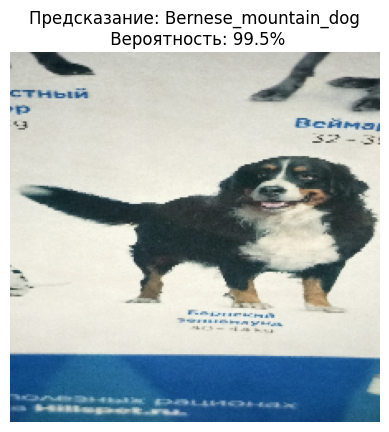

In [22]:
!wget https://storage.yandexcloud.net/my.files/dog2.jpg
TEST_IMG='/content/dog2.jpg'

img = keras.utils.load_img(TEST_IMG, target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1])) # Загружаем картинку
plt.imshow(img)


img_array = keras.utils.img_to_array(img) # Преобразуем картинку в тензор
img_array = keras.ops.expand_dims(img_array, 0)  # Создание дополнительного измерения для батча

predictions = model.predict(img_array)


plt.title("Предсказание: %s\n Вероятность: %2.1f%%" %
 (CLASS_LIST[keras.ops.argmax(predictions)],
  keras.ops.max(predictions)*100)  ) # Вывод метки
plt.axis("off")

--2026-04-02 18:43:23--  https://storage.yandexcloud.net/my.files/doberman2.jpg
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1123902 (1.1M) [image/jpeg]
Saving to: ‘doberman2.jpg’

doberman2.jpg       100%[===================>]   1.07M   674KB/s    in 1.6s    

2026-04-02 18:43:26 (674 KB/s) - ‘doberman2.jpg’ saved [1123902/1123902]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

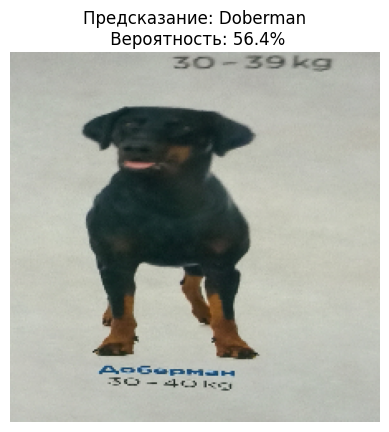

In [23]:
!wget https://storage.yandexcloud.net/my.files/doberman2.jpg
TEST_IMG='/content/doberman2.jpg'

img = keras.utils.load_img(TEST_IMG, target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1])) # Загружаем картинку
plt.imshow(img)


img_array = keras.utils.img_to_array(img) # Преобразуем картинку в тензор
img_array = keras.ops.expand_dims(img_array, 0)  # Создание дополнительного измерения для батча

predictions = model.predict(img_array)


plt.title("Предсказание: %s\n Вероятность: %2.1f%%" %
 (CLASS_LIST[keras.ops.argmax(predictions)],
  keras.ops.max(predictions)*100)  ) # Вывод метки
plt.axis("off")